# **Flooding Hazards caused by Hurricane Helene in North Carolina**

```{image} ../thumbnails/USGS_logo.png
:alt: USGS logo
:width: 200px
```

---

## **Overview**

This notebook utilizes data from the United States Geological Survey (USGS) water data website. Two locations across the Appalachian Mountains were selected based on the availability of data. We utilized the Matplotlib and Pandas packages for plotting and visualization, as well as handling time series and tabular datasets. The two selected locations were in Asheville and Sugar Grove, North Carolina. For this research, we plotted precipitation, discharge, and gauge height to visualize the correlation between these variables in the two locations. Then, we used data from the US Army Corps of Engineers (USACE) to visualize the streams and watersheds within the study area. According to the USACE, the combination of steep mountainous terrain and saturated soils significantly increases the likelihood of flash flooding. To visualize this dataset, we used pathlib, GeoPandas, NumPy, Matplotlib, and Cartopy to open the folder structure, read the shapefiles, and generate maps with multiple geographic features, including land, coastlines, and state boundaries. Lastly, we created an interactive map by downloading the USGS streamflow data. This interactive map shows the discharge across North Carolina during Hurricane Helene. 

1. Read in and process USGS water data for two selected locations (Asheville and Sugar Grove, NC).
2. Use Pandas and Matplotlib to plot precipitation, discharge, and gauge height time series.
3. Load and visualize USACE stream and watershed shapefiles to examine hydrologic features in the study area.
4. Generate geographic maps using pathlib, GeoPandas, NumPy, Matplotlib, and Cartopy. 
5. Analyze how steep terrain and saturated soils contributed to flooding hazards, based on USACE information.
6. Create an interactive map showing streamflow discharge across North Carolina during Hurricane Helene.

:::{note}
Data was obtained from the [**United States Geological Survey water data website**](https://waterdata.usgs.gov/) and [**US Army Corps of Engineers**](https://www.usace.army.mil/Media/Fact-Sheets/Fact-Sheets-View/Article/4272569/hurricane-helene-flood-data-collection/)
:::

---

## **Imports** 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import geopandas as gpd
from pathlib import Path
import pyogrio
import requests
from datetime import datetime, timedelta
import geoviews as gv
from geoviews import opts
import holoviews as hv
import os

---

### **North Carolina map**

For this research, we selected two locations in the area affected by Hurricane Helene's rainfall to compare the flooding hazards and landslides in the area. 

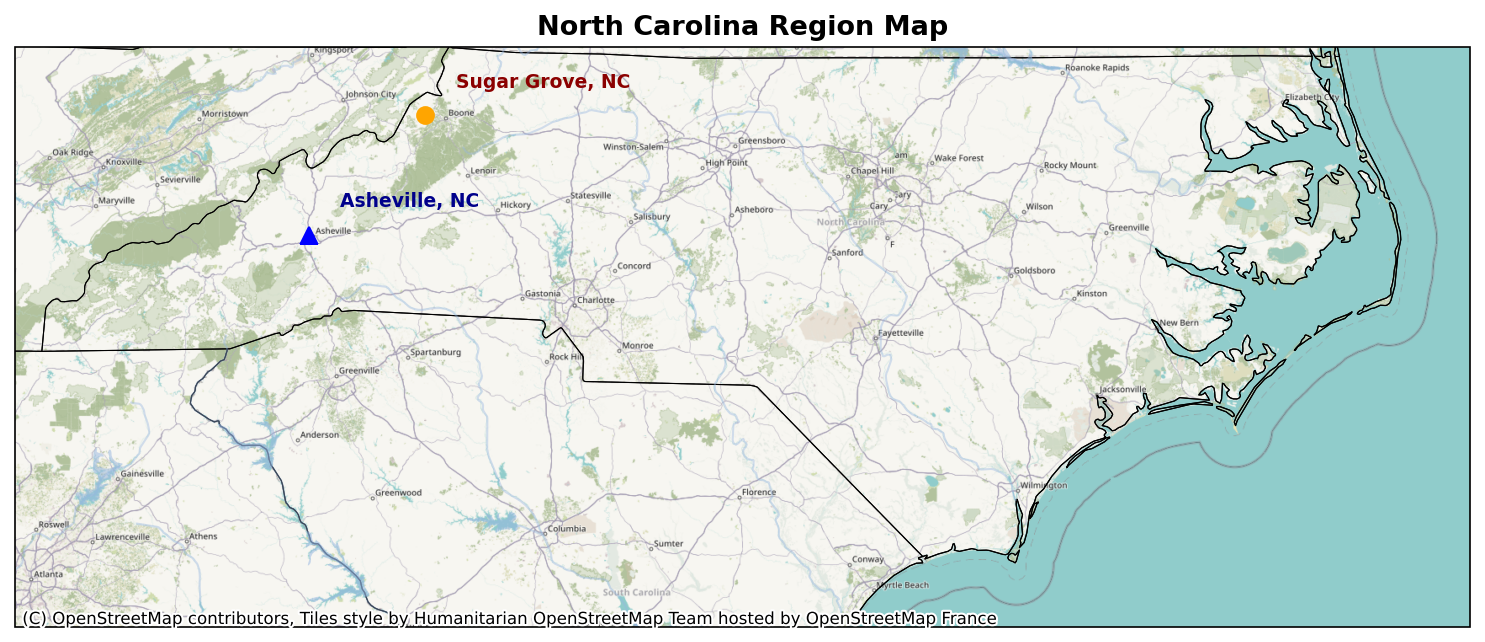

In [2]:
# North Carolina Domain
latS, latN = 33.5, 36.6
lonW, lonE = -84.5, -75.0
res = "10m"

# Station locations
lat_wat, lon_wat = 36.2391667, -81.8222222   # Watauga River near Sugar Grove, NC
lat_ash, lon_ash = 35.608889,  -82.578056    # Asheville, NC

# WebMercator for Contextily
proj = ccrs.epsg(3857)

fig = plt.figure(figsize=(10, 10), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=proj)

# Convert extent from lat/lon (WebMercator)
ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

# Cartopy features
ax.add_feature(cfeature.COASTLINE.with_scale(res), linewidth=0.6)
ax.add_feature(cfeature.STATES.with_scale(res), linewidth=0.5)
ax.add_feature(cfeature.LAKES.with_scale(res), alpha=0.5)
ax.add_feature(cfeature.RIVERS.with_scale(res), alpha=0.4)

# Stations
ax.plot(lon_wat, lat_wat, marker="o", color="orange", markersize=8, transform=ccrs.PlateCarree(), label="Sugar Grove, NC")

ax.plot(lon_ash, lat_ash, marker="^", color="blue", markersize=8, transform=ccrs.PlateCarree(), label="Asheville, NC")

# Labels
ax.text(lon_wat + 0.2, lat_wat + 0.15, "Sugar Grove, NC", transform=ccrs.PlateCarree(), fontsize=9, fontweight="bold", color="darkred")

ax.text(lon_ash + 0.2, lat_ash + 0.15, "Asheville, NC", transform=ccrs.PlateCarree(), fontsize=9, fontweight="bold", color="darkblue")

# Add Contextily basemap
ctx.add_basemap(ax, zoom=8, crs="EPSG:3857")

ax.set_title("North Carolina Region Map", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## **Time series**

### **Asheville, NC**  
[USGS 03451500 — French Broad River at Asheville, NC](https://waterdata.usgs.gov/monitoring-location/USGS-03451500/#dataTypeId=continuous-00065-0&period=P7D&showFieldMeasurements=true)

In [3]:
df_nc = pd.read_csv("2waterdata.usgs.csv", comment="#", sep="\t")

# Clean up column names for clarity
df_nc.rename(columns={
    "90198_00060": "discharge_cfs",
    "90199_00065": "gage_height_ft",
    "90202_00045": "precip_in"
}, inplace=True)

# Convert datetime and numeric columns
df_nc["datetime"] = pd.to_datetime(df_nc["datetime"], errors="coerce")
for c in ["discharge_cfs", "gage_height_ft", "precip_in"]:
    df_nc[c] = pd.to_numeric(df_nc[c], errors="coerce")

# Set datetime as index
df_nc = df_nc.dropna(subset=["datetime"]).set_index("datetime").sort_index()

#df_nc[["discharge_cfs", "gage_height_ft", "precip_in"]].head()

/tmp/ipykernel_1389670/3814503253.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_nc["datetime"] = pd.to_datetime(df_nc["datetime"], errors="coerce")


Two time series plots comparing precipitation, river discharge, and gage height at the USGS French Broad River station in Asheville, NC, to visualize how rainfall relates to rising water levels during Hurricane Helene.

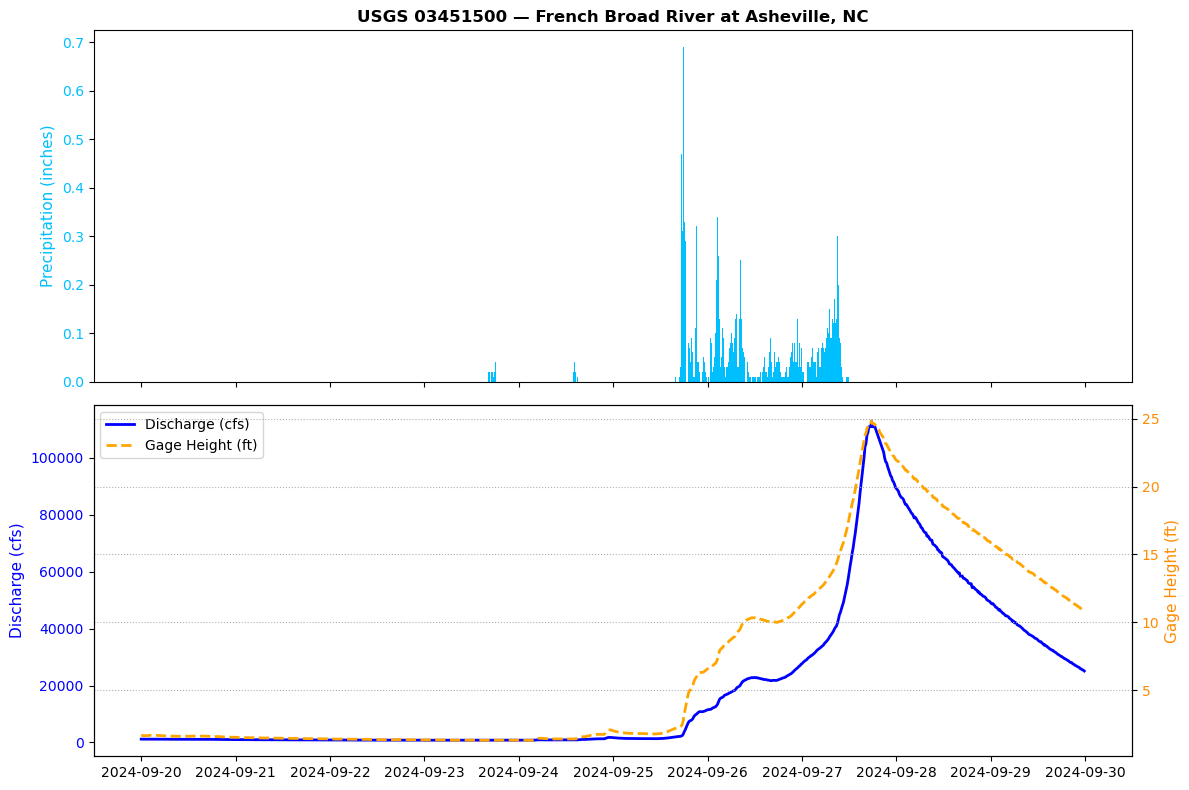

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Precipitation
ax1.bar(df_nc.index, df_nc["precip_in"], color="deepskyblue", width=0.01)
ax1.set_ylabel("Precipitation (inches)", color="deepskyblue", fontsize=11)
ax1.tick_params(axis="y", labelcolor="deepskyblue")
ax1.set_title("USGS 03451500 — French Broad River at Asheville, NC", fontweight="bold")

# Discharge and Gage Height
ax2.plot(df_nc.index, df_nc["discharge_cfs"], color="blue", linewidth=2, label="Discharge (cfs)")
ax2.set_ylabel("Discharge (cfs)", color="blue", fontsize=11)
ax2.tick_params(axis="y", labelcolor="blue")

ax3 = ax2.twinx()
ax3.plot(df_nc.index, df_nc["gage_height_ft"], color="orange", linestyle="--", linewidth=2, label="Gage Height (ft)")
ax3.set_ylabel("Gage Height (ft)", color="darkorange", fontsize=11)
ax3.tick_params(axis="y", labelcolor="darkorange")

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.xlabel("Datetime")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

---

### **Sugar Grove, NC** 
[USGS 03479000 — Watauga River Monitoring Station](https://waterdata.usgs.gov/monitoring-location/USGS-03479000/#dataTypeId=continuous-00065-0&period=P7D&showFieldMeasurements=true)

In [5]:
df_nc = pd.read_csv("3waterdata.usgs.csv", comment="#", sep="\t")

# Clean up column names for clarity
df_nc.rename(columns={
    "90260_00060": "discharge_cfs",
    "242355_00065": "gage_height_ft",
    "239343_00045": "precip_in"
}, inplace=True)

# Convert datetime and numeric columns
df_nc["datetime"] = pd.to_datetime(df_nc["datetime"], errors="coerce")
for c in ["discharge_cfs", "gage_height_ft", "precip_in"]:
    df_nc[c] = pd.to_numeric(df_nc[c], errors="coerce")

# Set datetime as index
df_nc = df_nc.dropna(subset=["datetime"]).set_index("datetime").sort_index()

#df_nc[["discharge_cfs", "gage_height_ft", "precip_in"]].head()

/tmp/ipykernel_1389670/2949748297.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_nc["datetime"] = pd.to_datetime(df_nc["datetime"], errors="coerce")


Two time series plots comparing precipitation, river discharge, and gage height at the USGS Watauga River station in Sugar Grove, NC, to visualize how rainfall relates to rising water levels during Hurricane Helene.

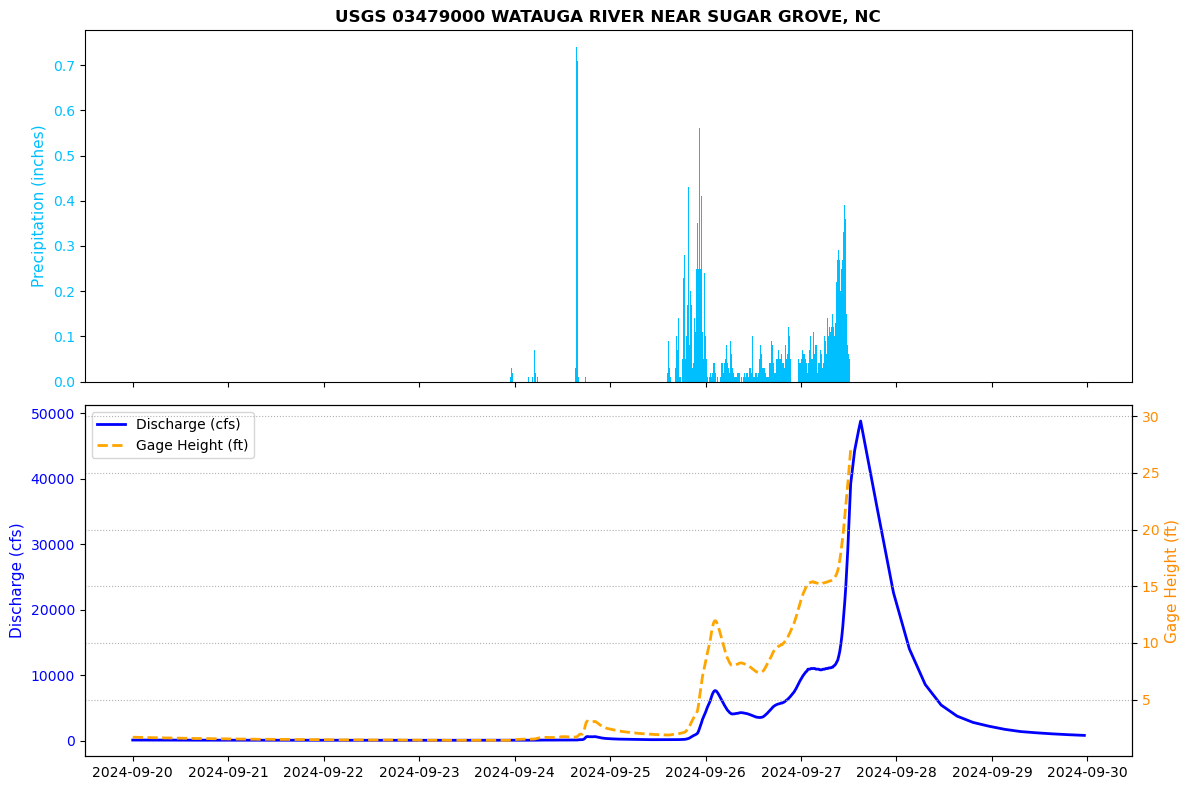

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Precipitation
ax1.bar(df_nc.index, df_nc["precip_in"], color="deepskyblue", width=0.01)
ax1.set_ylabel("Precipitation (inches)", color="deepskyblue", fontsize=11)
ax1.tick_params(axis="y", labelcolor="deepskyblue")
ax1.set_title("USGS 03479000 WATAUGA RIVER NEAR SUGAR GROVE, NC", fontweight="bold")

# Discharge and Gage Height
ax2.plot(df_nc.index, df_nc["discharge_cfs"], color="blue", linewidth=2, label="Discharge (cfs)")
ax2.set_ylabel("Discharge (cfs)", color="blue", fontsize=11)
ax2.tick_params(axis="y", labelcolor="blue")

ax3 = ax2.twinx()
ax3.plot(df_nc.index, df_nc["gage_height_ft"], color="orange", linestyle="--", linewidth=2, label="Gage Height (ft)")
ax3.set_ylabel("Gage Height (ft)", color="darkorange", fontsize=11)
ax3.tick_params(axis="y", labelcolor="darkorange")

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.xlabel("Datetime")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

### Hurricane Helene Database

Lists the files inside the Hurricane Helene data folder (USACE)

In [7]:
folder = Path("FINAL_HURRICANE_HELENE_HWM_PRODUCTS")

files = sorted([p for p in folder.rglob("*") if p.is_file()])

print(f"Total files: {len(files)}\n")
for p in files:
    print(p.relative_to(folder))

Total files: 158

01_REPORT/.ipynb_checkpoints/Hurricane_Helene_Post_Flood_Report-checkpoint.pdf
01_REPORT/Hurricane_Helene_Post_Flood_Report.pdf
02_EXCEL_DATABASE/Hurricane_Helene_HWM_Database_Table.xlsx
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000001.TablesByName.atx
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000001.gdbindexes
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000001.gdbtable
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000001.gdbtablx
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000002.gdbtable
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000002.gdbtablx
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000003.gdbindexes
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000003.gdbtable
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000003.gdbtablx
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000004.FDO_UUID.atx
03_GIS_GEODATABASE/Hurricane_Helene_HWM_Database.gdb/a00000

In [8]:
folder = Path("FINAL_HURRICANE_HELENE_HWM_PRODUCTS")

# Only list .shp files
shapefiles = sorted(folder.rglob("*.shp"))

print(f"Total shapefiles: {len(shapefiles)}\n")
for shp in shapefiles:
    print(shp.relative_to(folder))

Total shapefiles: 8

04_GIS_SHAPEFILES/Hurricane_Helene_Counties.shp
04_GIS_SHAPEFILES/Hurricane_Helene_HWM_Database_All_Features.shp
04_GIS_SHAPEFILES/Hurricane_Helene_HWM_Database_NC_Features.shp
04_GIS_SHAPEFILES/Hurricane_Helene_HWM_Database_TN_Features.shp
04_GIS_SHAPEFILES/Hurricane_Helene_HWM_Database_VA_Features.shp
04_GIS_SHAPEFILES/Hurricane_Helene_Streams.shp
04_GIS_SHAPEFILES/Hurricane_Helene_Watersheds.shp
04_GIS_SHAPEFILES/USACE_Nashville_District_Boundary.shp


Loading: FINAL_HURRICANE_HELENE_HWM_PRODUCTS/04_GIS_SHAPEFILES/Hurricane_Helene_Streams.shp


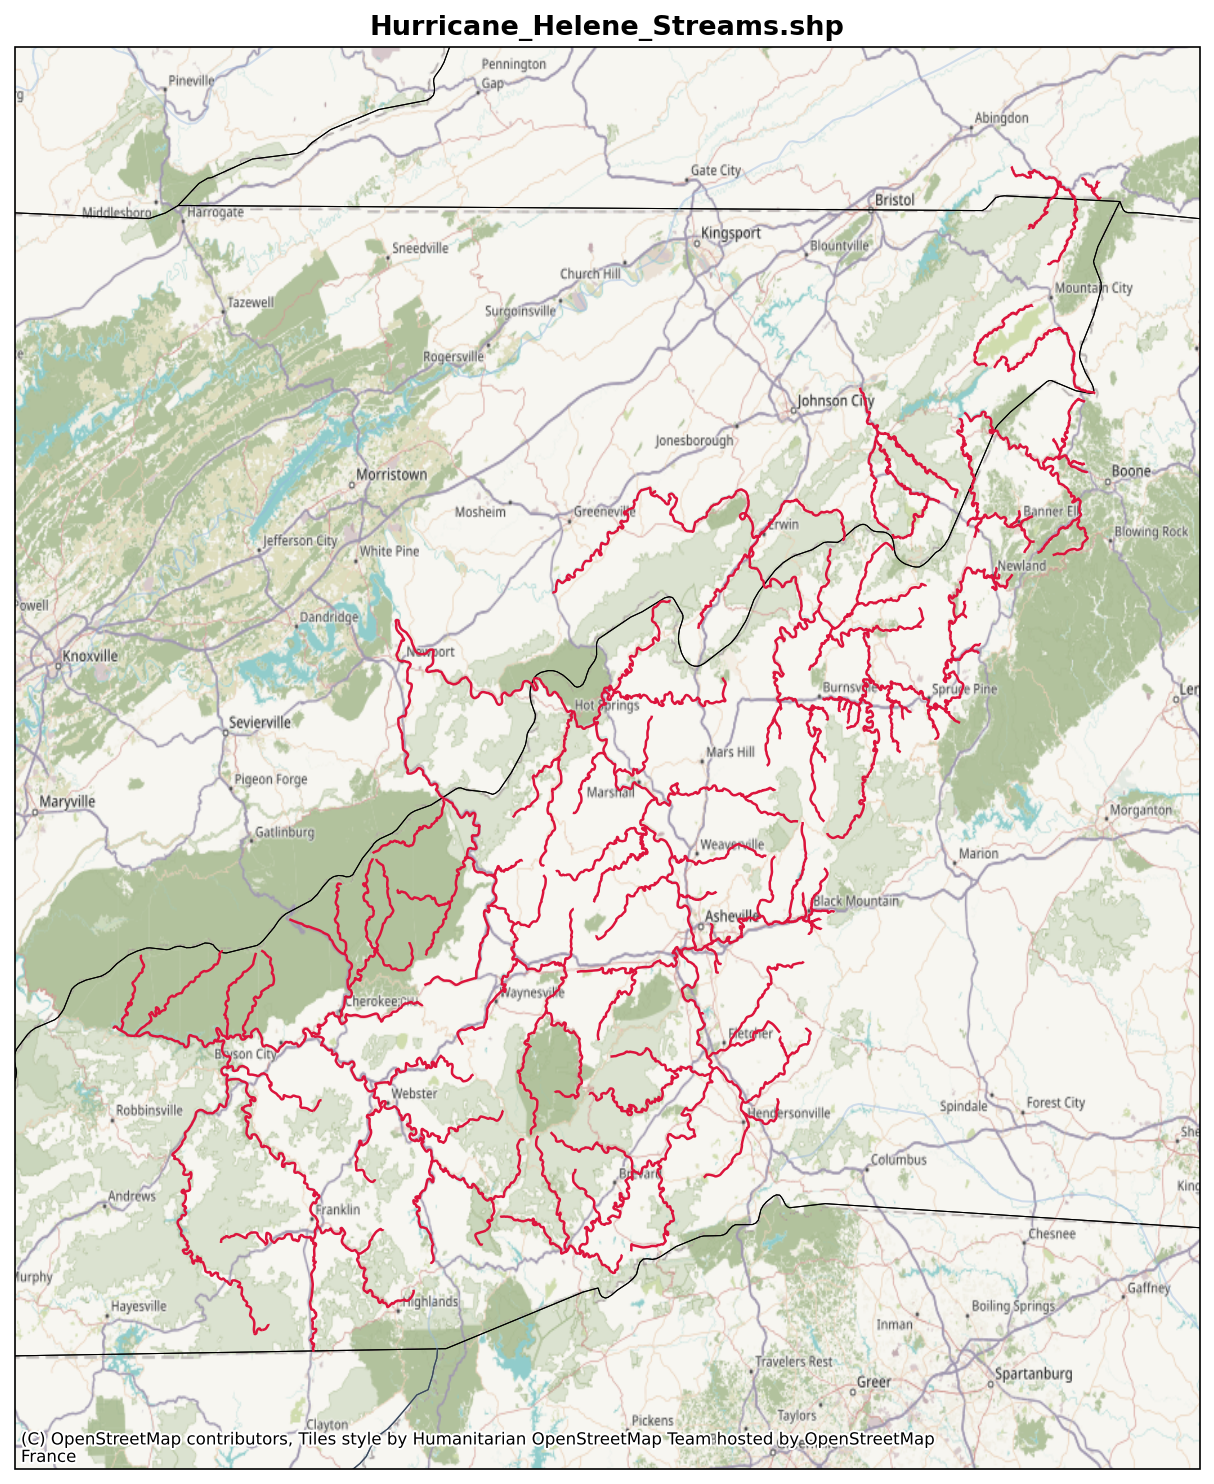

In [9]:
file_to_plot = "Hurricane_Helene_Streams.shp"

# Full path
shp_path = Path("FINAL_HURRICANE_HELENE_HWM_PRODUCTS/04_GIS_SHAPEFILES") / file_to_plot
print("Loading:", shp_path)

# Load and force to lat/lon projection (EPSG:4326)
gdf = gpd.read_file(shp_path).to_crs(epsg=4326)

# Map extent from geometry bounds
minx, miny, maxx, maxy = gdf.total_bounds
pad_x = (maxx - minx) * 0.10
pad_y = (maxy - miny) * 0.10
lonW, lonE = minx - pad_x, maxx + pad_x
latS, latN = miny - pad_y, maxy + pad_y

# Web Mercator for Contextily
proj = ccrs.epsg(3857)
res = "10m"

fig = plt.figure(figsize=(10, 10), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=proj)

# Set extent in lat/lon, Cartopy will project
ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

# Optional Cartopy features
ax.add_feature(cfeature.COASTLINE.with_scale(res), linewidth=0.6)
ax.add_feature(cfeature.STATES.with_scale(res), linewidth=0.5)
ax.add_feature(cfeature.LAKES.with_scale(res), alpha=0.5)
ax.add_feature(cfeature.RIVERS.with_scale(res), alpha=0.4)

# Plot streams (data are in lat/lon)
gdf.plot(ax=ax, transform=ccrs.PlateCarree(), linewidth=1.2, color="crimson",)

# Add Contextily basemap
ctx.add_basemap(ax, crs="EPSG:3857", zoom=9,)

ax.grid(True, linestyle=":", alpha=0.5)
ax.set_title(file_to_plot, fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

Loading: FINAL_HURRICANE_HELENE_HWM_PRODUCTS/04_GIS_SHAPEFILES/Hurricane_Helene_Watersheds.shp


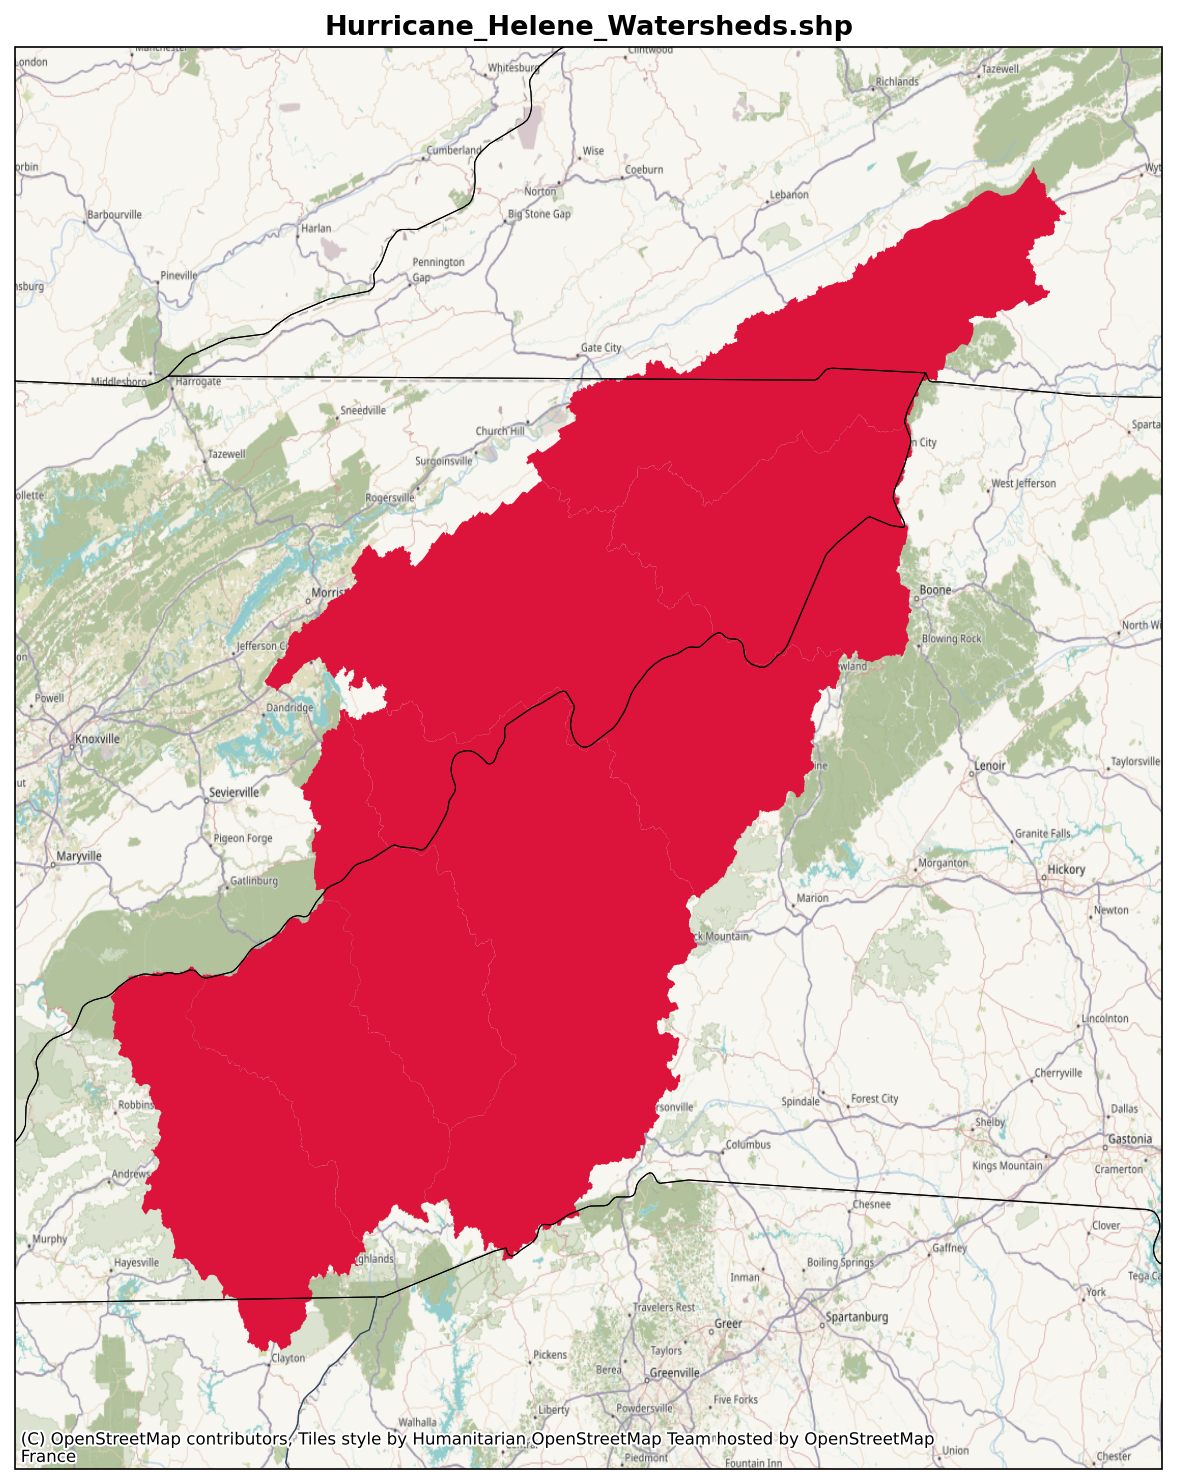

In [10]:
file_to_plot = "Hurricane_Helene_Watersheds.shp"

# Full path
shp_path = Path("FINAL_HURRICANE_HELENE_HWM_PRODUCTS/04_GIS_SHAPEFILES") / file_to_plot
print("Loading:", shp_path)

# Load and force to lat/lon projection (EPSG:4326)
gdf = gpd.read_file(shp_path).to_crs(epsg=4326)

# Map extent from geometry bounds
minx, miny, maxx, maxy = gdf.total_bounds
pad_x = (maxx - minx) * 0.10
pad_y = (maxy - miny) * 0.10
lonW, lonE = minx - pad_x, maxx + pad_x
latS, latN = miny - pad_y, maxy + pad_y

# Web Mercator for Contextily
proj = ccrs.epsg(3857)
res = "10m"

fig = plt.figure(figsize=(10, 10), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=proj)

# Set extent in lat/lon, Cartopy will project
ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

# Optional Cartopy features
ax.add_feature(cfeature.COASTLINE.with_scale(res), linewidth=0.6)
ax.add_feature(cfeature.STATES.with_scale(res), linewidth=0.5)
ax.add_feature(cfeature.LAKES.with_scale(res), alpha=0.5)
ax.add_feature(cfeature.RIVERS.with_scale(res), alpha=0.4)

# Plot streams (data are in lat/lon)
gdf.plot(ax=ax, transform=ccrs.PlateCarree(), linewidth=1.2, color="crimson",)

# Add Contextily basemap
ctx.add_basemap(ax, crs="EPSG:3857", zoom=9,)

ax.grid(True, linestyle=":", alpha=0.5)
ax.set_title(file_to_plot, fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

This code downloads USGS streamflow data across North Carolina during Hurricane Helene, processes it into hourly averages, and generates an interactive GeoViews map showing discharge at each monitoring station.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
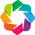

In [ ]:
gv.extension("bokeh")  # turn on interactive backend

# Define the analysis time window for Hurricane Helene
sd = datetime(2024, 9, 26, 0, 0)
ed = datetime(2024, 9, 29, 0, 0)

# Retrieve North Carolina stream gauges that report instantaneous discharge (00060)
site_url = (
    "https://waterservices.usgs.gov/nwis/site/"
    "?format=rdb"
    "&stateCd=NC"
    "&siteType=ST"
    "&hasDataTypeCd=iv"
    "&parameterCd=00060"
)

sites_raw = pd.read_csv(site_url, sep="\t", comment="#", dtype=str)
sites_raw["dec_lat_va"]  = pd.to_numeric(sites_raw["dec_lat_va"], errors="coerce")
sites_raw["dec_long_va"] = pd.to_numeric(sites_raw["dec_long_va"], errors="coerce")
sites = sites_raw.dropna(subset=["dec_lat_va", "dec_long_va"]).copy()

print("Total NC gauges:", len(sites))

# Function to download instantaneous discharge data for a group of sites
def fetch_iv_batch(site_nos, start_dt, end_dt):
    sites_str = ",".join(site_nos)
    iv_url = (
        "https://waterservices.usgs.gov/nwis/iv/"
        f"?format=json&sites={sites_str}"
        "&parameterCd=00060"
        f"&startDT={start_dt.isoformat()}&endDT={end_dt.isoformat()}"
        "&siteStatus=all"
    )
    r = requests.get(iv_url)
    r.raise_for_status()
    return r.json()

# Function to convert USGS JSON output into a clean dataframe
def parse_iv_json(j):
    rows = []
    for ts in j.get("value", {}).get("timeSeries", []):
        site_no = ts["sourceInfo"]["siteCode"][0]["value"]
        vals = ts["values"][0]["value"]
        for v in vals:
            rows.append({
                "site_no": site_no,
                "time": pd.to_datetime(v["dateTime"]),
                "discharge_cfs": pd.to_numeric(v["value"], errors="coerce")
            })
    return pd.DataFrame(rows)

# Download discharge data in batches to avoid request size limits
all_site_nos = sites["site_no"].tolist()
batch_size = 25

dfs = []
for i in range(0, len(all_site_nos), batch_size):
    batch = all_site_nos[i:i+batch_size]
    j = fetch_iv_batch(batch, sd, ed)
    dfs.append(parse_iv_json(j))
    print(f"batch {i//batch_size + 1} / {int(np.ceil(len(all_site_nos)/batch_size))}")

iv_df = pd.concat(dfs, ignore_index=True).dropna(subset=["discharge_cfs"])

# Add latitude, longitude, and station names to the discharge dataset
iv_df = iv_df.merge(
    sites[["site_no", "dec_lat_va", "dec_long_va", "station_nm"]],
    on="site_no", how="left"
).rename(columns={"dec_lat_va":"lat", "dec_long_va":"lon"})

# Aggregate observations to hourly resolution
iv_df["TimeBin"] = iv_df["time"].dt.floor("1h")
iv_bin = (iv_df.groupby(["site_no","station_nm","lat","lon","TimeBin"], as_index=False)
                 .agg(discharge_cfs=("discharge_cfs","mean")))

# Build a GeoViews dataset for interactive mapping
gv_ds = gv.Dataset(iv_bin, kdims=["TimeBin","lon","lat"],
                          vdims=["discharge_cfs","station_nm","site_no"])

# Convert to a GeoViews points object
points = gv_ds.to(gv.Points, ["lon","lat"], vdims=["discharge_cfs","station_nm","site_no"])

# Interactive map
points = points.opts(
    opts.Points(
        width=1000, height=800,
        color="discharge_cfs", cmap="Viridis",
        size=6, alpha=0.8,
        tools=["hover"], colorbar=True,
        framewise=False,
        title="NC River Discharge During Hurricane Helene (USGS 00060)"
    )
)

# Overlay points on an OSM basemap
layout = gv.tile_sources.OSM * points
layout

In [ ]:
sites_raw.head()

In [ ]:
sites.head()

In [ ]:
iv_df.head()

In [ ]:
iv_bin.head()

In [ ]:
# Use hourly averaged discharge values for plotting
df_plot = iv_bin.copy()

# Generate a time series plot for each USGS station
for site_no, g in df_plot.groupby("site_no"):
    
    # Extract the station name (fallback to site number if missing)
    station_nm = g["station_nm"].iloc[0] if "station_nm" in g else site_no
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot discharge time series
    ax.plot(g["TimeBin"], g["discharge_cfs"], linewidth=1.5)
    ax.set_title(f"{station_nm} (USGS {site_no})", fontweight="bold")
    ax.set_ylabel("Discharge (cfs)")
    ax.set_xlabel("Time")
    ax.grid(True, linestyle=":")
    
    # Datetime label readability
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()